# Regresión por Mínimos Cuadrados

## 1. Introducción

La regresión por mínimos cuadrados es una técnica fundamental en el análisis de datos experimentales que permite encontrar relaciones entre variables cuando existe variabilidad significativa en las mediciones.

### 1.1 Motivación

En datos experimentales, la interpolación polinomial puede resultar inadecuada debido a:
- Alta variabilidad en las observaciones
- Presencia de errores experimentales
- Tendencia a producir oscilaciones no deseadas
- Predicciones poco fiables en valores intermedios


![](img/minimos_cuadrados.png)


## 2. Limitaciones de la Interpolación

### 2.1 Problema Principal

Cuando se tienen datos experimentales con variabilidad, la interpolación polinomial puede:
- Crear oscilaciones artificiales
- Sobreajustar los datos
- Generar predicciones poco confiables
- Producir comportamientos erráticos entre puntos

### 2.2 Ejemplo Visual

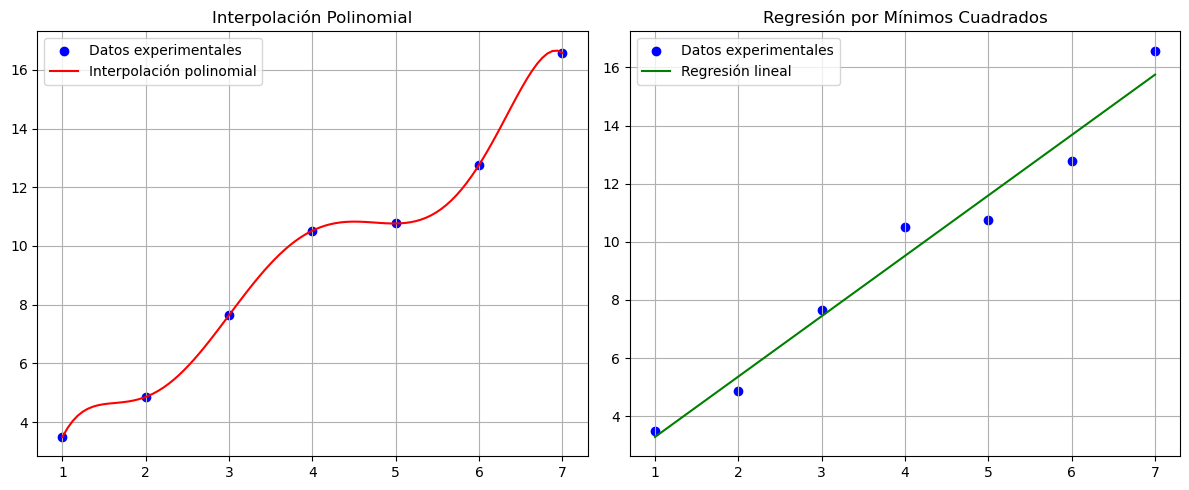

<module 'matplotlib.pyplot' from '/home/lgomez/miniconda3/lib/python3.8/site-packages/matplotlib/pyplot.py'>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Generación de datos de ejemplo
np.random.seed(42)
x = np.array([1, 2, 3, 4, 5, 6, 7])
y = 2*x + 1 + np.random.normal(0, 1, 7)

# Función para graficar datos y ajustes
def plot_comparison():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Datos originales y polinomio de alto grado
    ax1.scatter(x, y, color='blue', label='Datos experimentales')
    p = np.polyfit(x, y, 6)
    x_fine = np.linspace(min(x), max(x), 100)
    y_poly = np.polyval(p, x_fine)
    ax1.plot(x_fine, y_poly, 'r-', label='Interpolación polinomial')
    ax1.set_title('Interpolación Polinomial')
    ax1.legend()
    ax1.grid(True)
    
    # Datos originales y ajuste lineal
    ax2.scatter(x, y, color='blue', label='Datos experimentales')
    p_linear = np.polyfit(x, y, 1)
    y_linear = np.polyval(p_linear, x_fine)
    ax2.plot(x_fine, y_linear, 'g-', label='Regresión lineal')
    ax2.set_title('Regresión por Mínimos Cuadrados')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    
    plt.show()
    return plt

plot_comparison()


## 3. Fundamentos de la Regresión por Mínimos Cuadrados

### 3.1 Modelo Matemático

Para un conjunto de puntos $(x_1, y_1), (x_2, y_2), \ldots, (x_n, y_n)$, el modelo lineal se expresa como:

$$ y = a_0 + a_1x + e $$

donde:
- $a_0$ = intersección con el eje y
- $a_1$ = pendiente
- $e$ = error o residuo

### 3.2 Criterio de Minimización

El método minimiza la suma de los cuadrados de los residuos:

$$ S_r = \sum_{i=1}^{n} (y_i - a_0 - a_1 x_i)^2 $$

### 3.3 Ecuaciones Normales

Para encontrar los coeficientes óptimos, se resuelve:

$$ \frac{\partial S_r}{\partial a_0} = 0 \quad \text{y} \quad \frac{\partial S_r}{\partial a_1} = 0 $$

Lo que lleva a:

$$ \begin{align*}
na_0 + a_1\sum x_i &= \sum y_i \\
a_0\sum x_i + a_1\sum x_i^2 &= \sum x_iy_i
\end{align*} $$

## 4. Evaluación de la Calidad del Ajuste

### 4.1 Coeficiente de Determinación

El $r^2$ mide la proporción de variabilidad explicada por el modelo:

$$ r^2 = \frac{\sum (\hat{y}_i - \bar{y})^2}{\sum (y_i - \bar{y})^2} $$

donde:
- $\hat{y}_i$ son los valores predichos
- $\bar{y}$ es la media de los valores observados

### 4.2 Error Estándar de la Estimación

$$ s_{y/x} = \sqrt{\frac{\sum (y_i - \hat{y}_i)^2}{n-2}} $$


![](img/error.png)

## 5. Implementación en Python

In [3]:
def regresion_minimos_cuadrados(x, y):
    """
    Realiza regresión por mínimos cuadrados y retorna estadísticas relevantes
    """
    n = len(x)
    
    # Cálculo de sumas
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.sum(x * y)
    sum_x2 = np.sum(x**2)
    
    # Cálculo de coeficientes
    a1 = (n*sum_xy - sum_x*sum_y) / (n*sum_x2 - sum_x**2)
    a0 = (sum_y - a1*sum_x) / n
    
    # Cálculo de y predicho
    y_pred = a0 + a1*x
    
    # Cálculo de r^2
    y_mean = np.mean(y)
    ss_tot = np.sum((y - y_mean)**2)
    ss_res = np.sum((y - y_pred)**2)
    r2 = 1 - (ss_res/ss_tot)
    
    # Error estándar
    se = np.sqrt(ss_res/(n-2))
    
    return {
        'a0': a0,
        'a1': a1,
        'r2': r2,
        'se': se,
        'y_pred': y_pred
    }
regresion_minimos_cuadrados(x, y)

{'a0': 1.2094545667250347,
 'a1': 2.0776395986824427,
 'r2': 0.971490944581249,
 'se': 0.8422407758280096,
 'y_pred': array([ 3.28709417,  5.36473376,  7.44237336,  9.52001296, 11.59765256,
        13.67529216, 15.75293176])}

## 6. Ventajas y Limitaciones

### Ventajas:
1. Proporciona un criterio objetivo de ajuste
2. Minimiza el efecto de valores atípicos
3. Permite cuantificar la calidad del ajuste
4. Produce resultados únicos y reproducibles

### Limitaciones:
1. Asume relación lineal entre variables
2. Sensible a valores extremos
3. Requiere independencia de observaciones
4. No garantiza causalidad

## 7. Ejercicios Propuestos

1. Implementar la regresión por mínimos cuadrados para un conjunto de datos experimentales
2. Comparar los resultados con interpolación polinomial
3. Calcular e interpretar intervalos de confianza para los coeficientes
4. Analizar residuos para validar supuestos del modelo

## Referencias

1. Chapra, S. C., & Canale, R. P. (2015). Numerical Methods for Engineers (7th ed.). McGraw-Hill.
2. Press, W. H., et al. (2007). Numerical Recipes: The Art of Scientific Computing (3rd ed.). Cambridge University Press.
3. Montgomery, D. C., et al. (2012). Introduction to Linear Regression Analysis (5th ed.). Wiley.